# What is the most optimal skill to learn for Data Analysts?

#### Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

#### Original Exploration

[15_Matplotlib_Scatter_Plots.ipynb](../2_Advanced/15_Matplotlib_Scatter_Plots.ipynb)  
[16_Matplotlib_Advanced_Customization.ipynb](../2_Advanced/16_Matplotlib_Advanced_Customization.ipynb)

## Import Libraries and Data

Import the libraries, data and change the `job_posted_date` to a datetime type.

In [1]:
# Importing libraries
import ast  # used later to parse the job_type_skills column

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_data

# Load the cleaned data_jobs dataset.
# First run downloads it from Hugging Face and caches it to data/data_jobs.parquet;
# every later run reads that cache instead. See load_data.py for the details.
df = load_data()

## Clean Data

Filters the original dataset to only get rows where the job title is 'Data Analyst' and a country of your choosing, to create a new DataFrame `df_country_da`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in a new DataFrame (`df_country_da_exploded`) for each skill associated with a job. Finally, it displays the first 5 entries of the `salary_year_avg` and `job_skills` columns.

In [2]:
from config import SELECTED_COUNTRY, BENCHMARK_COUNTRY, MIN_SKILL_COUNT

# filename-safe form of the country, used when saving chart images (e.g. "united_kingdom")
country_slug = SELECTED_COUNTRY.lower().replace(" ", "_")

df_country_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == SELECTED_COUNTRY)].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_country_da = df_country_da.dropna(subset=['salary_year_avg'])

df_country_da_exploded = df_country_da.explode('job_skills')

# Same slice for the benchmark market, used later to place reference points on the plots.
df_benchmark_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == BENCHMARK_COUNTRY)].dropna(subset=['salary_year_avg'])
df_benchmark_da_exploded = df_benchmark_da.explode('job_skills')

df_country_da_exploded[['salary_year_avg', 'job_skills']].head(5)
# df_country_da_exploded

,salary_year_avg,job_skills
2602,51014.0,excel
2602,51014.0,word
2602,51014.0,outlook
16526,100500.0,sql
16526,100500.0,jupyter


## Calculate Percent of Job Postings that Have Skills

Group the data by job skills and calculate the count and median salary for each skill, sorted by count. Rename the columns, then calculate `skill_percent` — the share of Data Analyst jobs that list each skill. Finally, **keep only skills with at least `MIN_SKILL_COUNT` postings** so every median salary shown rests on a usable sample.

In [3]:
# using df_country_da_exploded find the count of skills and also the median salary for each skill
df_country_da_skills = df_country_da_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_country_da_skills = df_country_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

country_da_job_count = len(df_country_da)  # find count of Data Analyst jobs in selected country with salary info

df_country_da_skills['skill_percent'] = df_country_da_skills['skill_count'] / country_da_job_count * 100

# Reliability floor: keep only skills backed by enough postings to trust the median.
n_skills_all = len(df_country_da_skills)
df_country_da_skills = df_country_da_skills[df_country_da_skills['skill_count'] >= MIN_SKILL_COUNT]
print(f'{len(df_country_da_skills)} of {n_skills_all} skills have >= {MIN_SKILL_COUNT} postings '
      f'(dropped {n_skills_all - len(df_country_da_skills)}).')

df_country_da_skills

12 of 62 skills have >= 5 postings (dropped 50).


,skill_count,median_salary,skill_percent
job_skills,,,
sql,33,98500.0,45.833333
excel,29,75550.0,40.277778
python,25,89100.0,34.722222
tableau,13,100500.0,18.055556
r,9,77017.5,12.500000
go,9,71000.0,12.500000
sas,8,80007.0,11.111111
power bi,7,89100.0,9.722222
looker,6,96012.5,8.333333


## Median Salary vs Percent Skill Demand

Filter for Data Analyst skills that appear in more than `skill_limit` percent of postings.

The two filters do different jobs: `MIN_SKILL_COUNT` (above) is a *reliability* floor — enough postings to trust the median salary — while `skill_limit` here is a *relevance* floor — common enough to be worth learning. On a small market both can bite; on a large one `skill_limit` does most of the trimming.

In [4]:
skill_limit = 3   # % of postings; course original used 5, lowered for this market

df_country_da_skills_high_demand = df_country_da_skills[df_country_da_skills['skill_percent'] > skill_limit]
df_country_da_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,33,98500.0,45.833333
excel,29,75550.0,40.277778
python,25,89100.0,34.722222
tableau,13,100500.0,18.055556
r,9,77017.5,12.500000
go,9,71000.0,12.500000
sas,8,80007.0,11.111111
power bi,7,89100.0,9.722222
looker,6,96012.5,8.333333


Create a scatter plot to visualize the relationship between the percentage of Data Analyst jobs that require specific skills and the median salary for those skills. Point labels include `n`, the number of postings behind each skill's median. Hollow gray points show the same skills in the benchmark market, each joined to its selected-market point by a line.

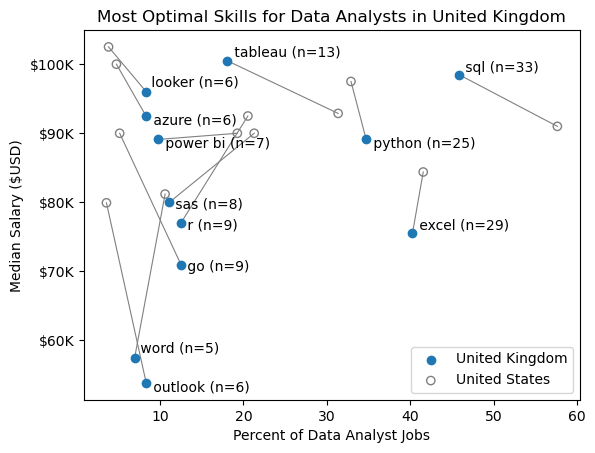

In [5]:
from adjustText import adjust_text

plt.scatter(df_country_da_skills_high_demand['skill_percent'], df_country_da_skills_high_demand['median_salary'], zorder=3)
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in ' + SELECTED_COUNTRY)

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Benchmark: plot each skill's position in the benchmark market as a hollow point,
# joined to the selected-market point, so both the demand shift and the pay shift show.
if BENCHMARK_COUNTRY != SELECTED_COUNTRY:
    bench_skills = df_benchmark_da_exploded.groupby('job_skills')['salary_year_avg'].agg(skill_count='count', median_salary='median')
    bench_skills['skill_percent'] = bench_skills['skill_count'] / len(df_benchmark_da) * 100
    for skill in df_country_da_skills_high_demand.index:
        if skill in bench_skills.index:
            x0 = df_country_da_skills_high_demand.loc[skill, 'skill_percent']
            y0 = df_country_da_skills_high_demand.loc[skill, 'median_salary']
            x1, y1 = bench_skills.loc[skill, ['skill_percent', 'median_salary']]
            ax.plot([x0, x1], [y0, y1], color='gray', lw=0.8, zorder=1)
            ax.scatter(x1, y1, facecolors='none', edgecolors='gray', zorder=2)
    ax.scatter([], [], color='C0', label=SELECTED_COUNTRY)
    ax.scatter([], [], facecolors='none', edgecolors='gray', label=BENCHMARK_COUNTRY)
    ax.legend()

# Add labels to points (skill name + n, the postings behind its median) and collect them
texts = []
for i, txt in enumerate(df_country_da_skills_high_demand.index):
    n = int(df_country_da_skills_high_demand['skill_count'].iloc[i])
    texts.append(plt.text(df_country_da_skills_high_demand['skill_percent'].iloc[i], df_country_da_skills_high_demand['median_salary'].iloc[i], f" {txt} (n={n})"))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.savefig(f'images/optimal_skills_da_{country_slug}.png', bbox_inches='tight', dpi=150)
plt.show()

## Bonus: Coloring by Technology

We're going to add color labels based on technology.

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [6]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['power bi',
  'tableau',
  'word',
  'ssrs',
  'ms access',
  'sas',
  'powerbi',
  'splunk',
  'nuix',
  'looker',
  'datarobot',
  'sap',
  'sheets',
  'spss',
  'microstrategy',
  'msaccess',
  'esquisse',
  'powerpoint',
  'dax',
  'sharepoint',
  'cognos',
  'outlook',
  'alteryx',
  'ssis',
  'qlik',
  'spreadsheet',
  'visio',
  'excel'],
 'programming': ['matlab',
  'delphi',
  'ruby',
  'crystal',
  'c#',
  'rust',
  'clojure',
  'sass',
  'ocaml',
  'mongodb',
  'nosql',
  'python',
  'css',
  'html',
  'elixir',
  'sas',
  'pascal',
  'php',
  'apl',
  'c++',
  'perl',
  'visualbasic',
  'go',
  'lua',
  'no-sql',
  'dart',
  'mongo',
  'bash',
  'sql',
  'scala',
  'lisp',
  'vba',
  'cobol',
  'r',
  'shell',
  'erlang',
  'typescript',
  'f#',
  'objective-c',
  'visual basic',
  'golang',
  'fortran',
  'julia',
  'kotlin',
  'c',
  'java',
  'haskell',
  'assembly',
  'powershell',
  'solidity',
  'vb.net',
  'swift',
  'groovy',
  't-sql',
  'javascr

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [7]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,power bi
0,analyst_tools,tableau
0,analyst_tools,word
0,analyst_tools,ssrs
0,analyst_tools,ms access
...,...,...
9,sync,symphony
9,sync,slack
9,sync,zoom
9,sync,rocketchat


Merges two DataFrames, `df_country_da_skills` and `df_technology`, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame `df_country_da_skills_tech`.

In [8]:
# merge df_country_da_skills and df_technology
df_country_da_skills_tech = df_country_da_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_country_da_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,33,98500.0,45.833333,programming,sql
1,29,75550.0,40.277778,analyst_tools,excel
2,25,89100.0,34.722222,programming,python
3,13,100500.0,18.055556,analyst_tools,tableau
4,9,77017.5,12.500000,programming,r
5,9,71000.0,12.500000,programming,go
6,8,80007.0,11.111111,analyst_tools,sas
7,8,80007.0,11.111111,programming,sas
8,7,89100.0,9.722222,analyst_tools,power bi
9,6,96012.5,8.333333,analyst_tools,looker


Filters `df_country_da_skills_tech` to select rows where the 'percent' column exceeds a specified threshold, storing the result in `df_country_da_skills_tech_high_demand`. 

In [9]:
df_country_da_skills_tech_high_demand = df_country_da_skills_tech[df_country_da_skills_tech['skill_percent'] > skill_limit]
# df_country_da_skills_tech_high_demand

Plot the results in a scatter plot, coloring the points based on the 'technology' column. Hollow gray points and connectors show the benchmark market, as in the previous chart.

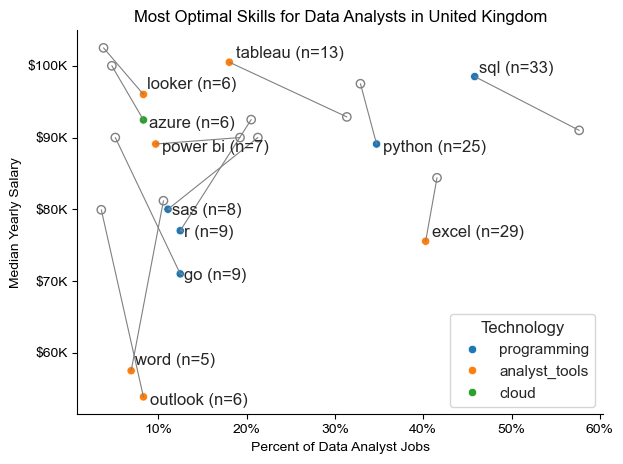

In [10]:
sns.scatterplot(
    data=df_country_da_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Benchmark reference: same skills in the benchmark market as hollow points + connectors.
if BENCHMARK_COUNTRY != SELECTED_COUNTRY:
    bench_skills = df_benchmark_da_exploded.groupby('job_skills')['salary_year_avg'].agg(skill_count='count', median_salary='median')
    bench_skills['skill_percent'] = bench_skills['skill_count'] / len(df_benchmark_da) * 100
    for skill in df_country_da_skills_high_demand.index:
        if skill in bench_skills.index:
            x0 = df_country_da_skills_high_demand.loc[skill, 'skill_percent']
            y0 = df_country_da_skills_high_demand.loc[skill, 'median_salary']
            x1, y1 = bench_skills.loc[skill, ['skill_percent', 'median_salary']]
            plt.plot([x0, x1], [y0, y1], color='gray', lw=0.8, zorder=1)
            plt.scatter(x1, y1, facecolors='none', edgecolors='gray', zorder=2)

# Prepare texts for adjustText (skill name + n, the postings behind its median)
texts = []
for i, txt in enumerate(df_country_da_skills_high_demand.index):
    n = int(df_country_da_skills_high_demand['skill_count'].iloc[i])
    texts.append(plt.text(df_country_da_skills_high_demand['skill_percent'].iloc[i], df_country_da_skills_high_demand['median_salary'].iloc[i], f"{txt} (n={n})"))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in ' + SELECTED_COUNTRY)
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.savefig(f'images/optimal_skills_da_colored_{country_slug}.png', bbox_inches='tight', dpi=150)
plt.show()